# FNCE 449 Day 1 Assignment: Pairs Trading

**Assignment Instructions:**

1. **Select two correlated instruments and download data**
    - Download two years of data (e.g., July 1, 2023, to July 1, 2025) for two correlated instruments from Databento.
    - **Save the files locally to prevent querying Databento each time you run the code**.
    - Use hourly OHLCV data to enable higher frequency trading.

2. **Train the quantitative model**
   - Use only the *first* year of data to train the model.
   - Compute the price ratio $R_t=\frac{P_A}{P_B}$ and estimate the in-class regression: $$R_t-R_{t-1}=c-d \times R_{t-1} + \epsilon$$.
   - Set the threshold ratio for trading $\frac{c}{d}$.

3. **Implement the strategy**
    - Use only the *second* year of data to implement the model.
    - When $R_t>\frac{c}{d}$, then buy one stock $B$ and go short one stock $A$.
    - When $R_t<\frac{c}{d}$, buy one stock $A$ and go short one stock $B$.
    - Do not exceed one stock position at any time.
    - Keep track of your cash flow and mark-to-market your position over time.

4. **Performance Evaluation**
   - Calculate and plot the dollar value of your long-short portfolio over time.
   - Plot the number of trades over time.

## 1. Instrument Selection and Setup

In [ ]:
import os
from io import StringIO

import pandas as pd
import requests
from requests.auth import HTTPBasicAuth

api_key = "db-RRkejP3pLR83aa7vkrtyTndLCNaey"
dataset = "XNAS.ITCH"
symbols = "ENB,TRP"
schema = "ohlcv-1h"
start = "2024-07-01"
end = "2026-07-01"


def get_range(api_key, dataset, symbols, schema, start, end, limit=None):
    """Query the Databento historical API and return the result as a DataFrame."""
    url = "https://hist.databento.com/v0/timeseries.get_range"
    auth = HTTPBasicAuth(api_key, "")

    payload = {
        "dataset": dataset,
        "symbols": symbols,
        "schema": schema,
        "start": start,
        "end": end,
        "encoding": "csv",
        "pretty_px": "true",
        "pretty_ts": "true",
        "map_symbols": "true",
        "limit": limit,
    }

    response = requests.post(url, auth=auth, data=payload)
    response.raise_for_status()
    return pd.read_csv(StringIO(response.content.decode("utf-8")))





## 2. Data Download

In [44]:
# Part 1: Download two-year hourly OHLCV for GOOGL and META and save to a single CSV
from pathlib import Path
import pandas as pd

out_file = Path('ENB_TRP_hourly_2024_2026.csv')
symbols = 'ENB,TRP'

if not out_file.exists():
    print(f'Querying Databento for: {symbols}')
    df = get_range(api_key, dataset, symbols, schema, start, end)
    # Save locally so we don't re-query every run
    df.to_csv(out_file, index=False)
else:
    print(f'Loading local file: {out_file}')
    df = pd.read_csv(out_file)

print('Data loaded. Shape =', df.shape)
try:
    display(df.head())
except Exception:
    print(df.head().to_string())

# Keep `df` available for subsequent cells


Loading local file: GOOGL_META_hourly_2024_2026.csv
Data loaded. Shape = (15666, 10)


,ts_event,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol
0,2024-07-01T08:00:00.000000000Z,34,2,10451,505.42,506.85,504.40,505.12,7170,META
1,2024-07-01T08:00:00.000000000Z,34,2,7152,182.31,183.05,182.22,182.90,6192,GOOGL
2,2024-07-01T09:00:00.000000000Z,34,2,7152,182.90,183.05,182.76,182.96,5847,GOOGL
3,2024-07-01T09:00:00.000000000Z,34,2,10451,505.29,505.44,504.65,505.29,2117,META
4,2024-07-01T10:00:00.000000000Z,34,2,7152,182.96,183.62,182.86,183.57,7135,GOOGL


## 2. Train Model on Y1 Data

In [ ]:
# Part 2: Train the quantitative model using ONLY the first year of data
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Read the combined CSV produced in Part 1
csv_path = 'ENB_TRP_hourly_2024_2026.csv'
df = pd.read_csv(csv_path, low_memory=False)

# Identify timestamp column (common names) and ensure datetime index
ts_col = None
for c in ['ts_event', 'timestamp', 'ts', 'time', 'datetime', 'date']:
    if c in df.columns:
        ts_col = c
        break
if ts_col is None:
    ts_col = df.columns[0]
df[ts_col] = pd.to_datetime(df[ts_col])

# Pivot to get close prices for each symbol indexed by timestamp
prices = (
    df.pivot_table(index=ts_col, columns='symbol', values='close', aggfunc='last')
    .sort_index()
    .dropna(subset=['ENB', 'TRP'])
)

# Price ratio R_t = P_A / P_B  (choose A=ENB, B=TRP)
prices['ratio'] = prices['ENB'] / prices['TRP']

# Define first-year training window (use inclusive start, exclusive end)
# Make the window timestamps timezone-aware if the data index is tz-aware
tz = df[ts_col].dt.tz
if tz is None:
    train_start = pd.Timestamp('2024-07-01')
    train_end = pd.Timestamp('2025-07-01')
else:
    train_start = pd.Timestamp('2024-07-01', tz=tz)
    train_end = pd.Timestamp('2025-07-01', tz=tz)

train = prices[(prices.index >= train_start) & (prices.index < train_end)].copy()

# Prepare regression data: R_t - R_{t-1} = c - d * R_{t-1} + eps
train['ratio_lag'] = train['ratio'].shift(1)
train['delta_ratio'] = train['ratio'] - train['ratio_lag']
reg_data = train.dropna(subset=['ratio_lag','delta_ratio']).copy()

# Run OLS regression: delta_ratio ~ 1 + ratio_lag
X = sm.add_constant(reg_data['ratio_lag'])
y = reg_data['delta_ratio']
model = sm.OLS(y, X).fit()

# Extract parameters and threshold c/d (as in lecture notes)
c = model.params.get('const', 0.0)
d = -model.params.get('ratio_lag', 0.0)
threshold = c / d if d != 0 else np.nan

# Simple diagnostics
return_corr = (train[['ENB','TRP']].pct_change().dropna().corr().loc['ENB','TRP'])
print('Training window:', train_start, 'to', train_end)
print('Observations used:', len(reg_data))
print('c =', c)
print('d =', d)
print('Threshold (c/d) =', threshold)
print('ENB-TRP hourly return correlation (train):', round(return_corr, 3))

# Keep variables for later cells
trained_model = model
train_prices = train
prices_all = prices

# Optionally show model summary (comment/uncomment as desired)
print(model.summary())


Training window: 2024-07-01 00:00:00+00:00 to 2025-07-01 00:00:00+00:00
Observations used: 3908
c = 0.0003437812662820177
d = 0.001276220487792601
Threshold (c/d) = 0.2693745082220351
GOOGL-META hourly return correlation (train): 0.633
                            OLS Regression Results                            
Dep. Variable:            delta_ratio   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     2.945
Date:                Tue, 25 Aug 2026   Prob (F-statistic):             0.0862
Time:                        10:40:24   Log-Likelihood:                 19877.
No. Observations:                3908   AIC:                        -3.975e+04
Df Residuals:                    3906   BIC:                        -3.974e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                

## 3. Implementing the Model

In [ ]:
# Part 3: Implement the pairs trading strategy on the second year
import numpy as np
import pandas as pd

# Define test window: the year after the training window
# `train_end` was defined in the previous cell
try:
    tz = train_end.tz
except Exception:
    tz = None
if tz is None:
    test_start = pd.Timestamp('2025-07-01')
    test_end = pd.Timestamp('2026-07-01')
else:
    test_start = pd.Timestamp('2025-07-01', tz=tz)
    test_end = pd.Timestamp('2026-07-01', tz=tz)

test = prices_all[(prices_all.index >= test_start) & (prices_all.index < test_end)].copy()

# Trading rule (as specified):
# If R_t > threshold -> buy one B (TRP) and short one A (ENB)
# If R_t < threshold -> buy one A (ENB) and short one B (TRP)
# Positions are -1 (short) or +1 (long) for each stock
if np.isnan(threshold):
    raise ValueError('Threshold is NaN — check training results before running the strategy')

test['position_ENB'] = np.where(test['ratio'] > threshold, -1, 1)
test['position_TRP'] = -test['position_ENB']

# Trades required to move between positions (number of shares to trade)
test['trade_ENB'] = test['position_ENB'].diff().fillna(test['position_ENB'])
test['trade_TRP'] = -test['trade_ENB']
test['trade_event'] = test['trade_ENB'] != 0

# Cash flow when trades happen: we buy/sell at the close price at that timestamp
test['cash_flow'] = -(test['trade_ENB'] * test['ENB'] + test['trade_TRP'] * test['TRP'])
test['cash'] = test['cash_flow'].cumsum()

# Mark-to-market value of open positions
test['market_value'] = test['position_ENB'] * test['ENB'] + test['position_TRP'] * test['TRP']
test['portfolio_value'] = test['cash'] + test['market_value']

# Show the first several rows including positions and portfolio metrics
cols = ['ENB','TRP','ratio','position_ENB','position_TRP','trade_ENB','trade_TRP','trade_event','cash_flow','cash','market_value','portfolio_value']
try:
    display(test[cols].head(12))
except Exception:
    print(test[cols].head(12).to_string())

# Show a concise sample of rows where trades occurred (do not replace the full view above)
trades = test[test['trade_event']]
print('\nTrades (showing first 20 trade events):')
# Print a compact text table of the first 20 trade rows to avoid rendering a second large rich display
print(trades[cols].head(20).to_string())

# Summary statistics
print('\nTotal trades:', int(test['trade_event'].sum()))
print('Final portfolio value:', round(test['portfolio_value'].iloc[-1],2))

# Keep `test` in the namespace for later evaluation/plots
test_results = test


symbol,GOOGL,META,ratio,position_GOOGL,position_META,trade_GOOGL,trade_META,trade_event,cash_flow,cash,market_value,portfolio_value
ts_event,,,,,,,,,,,,
2025-07-01 08:00:00+00:00,175.73,739.90,0.237505,1,-1,1.0,-1.0,True,564.17,564.17,-564.17,0.00
2025-07-01 09:00:00+00:00,175.81,739.17,0.237848,1,-1,0.0,-0.0,False,-0.00,564.17,-563.36,0.81
2025-07-01 10:00:00+00:00,176.37,738.40,0.238854,1,-1,0.0,-0.0,False,-0.00,564.17,-562.03,2.14
2025-07-01 11:00:00+00:00,176.13,738.00,0.238659,1,-1,0.0,-0.0,False,-0.00,564.17,-561.87,2.30
2025-07-01 12:00:00+00:00,175.72,735.98,0.238756,1,-1,0.0,-0.0,False,-0.00,564.17,-560.26,3.91
2025-07-01 13:00:00+00:00,174.92,734.97,0.237996,1,-1,0.0,-0.0,False,-0.00,564.17,-560.05,4.12
2025-07-01 14:00:00+00:00,174.30,725.03,0.240404,1,-1,0.0,-0.0,False,-0.00,564.17,-550.73,13.44
2025-07-01 15:00:00+00:00,174.83,719.39,0.243025,1,-1,0.0,-0.0,False,-0.00,564.17,-544.56,19.61
2025-07-01 16:00:00+00:00,174.86,721.19,0.242460,1,-1,0.0,-0.0,False,-0.00,564.17,-546.33,17.84



Trades (showing first 20 trade events):
symbol                      GOOGL     META     ratio  position_GOOGL  position_META  trade_GOOGL  trade_META  trade_event  cash_flow    cash  market_value  portfolio_value
ts_event                                                                                                                                                                   
2025-07-01 08:00:00+00:00  175.73  739.900  0.237505               1             -1          1.0        -1.0         True     564.17  564.17      -564.170            0.000
2025-07-22 16:00:00+00:00  190.39  704.700  0.270172              -1              1         -2.0         2.0         True   -1028.62 -464.45       514.310           49.860
2025-07-23 13:00:00+00:00  189.87  706.320  0.268816               1             -1          2.0        -2.0         True    1032.90  568.45      -516.450           52.000
2025-07-23 20:00:00+00:00  192.85  714.810  0.269792              -1              1         -2.0   

# 4. Performance Evaluation and Charts

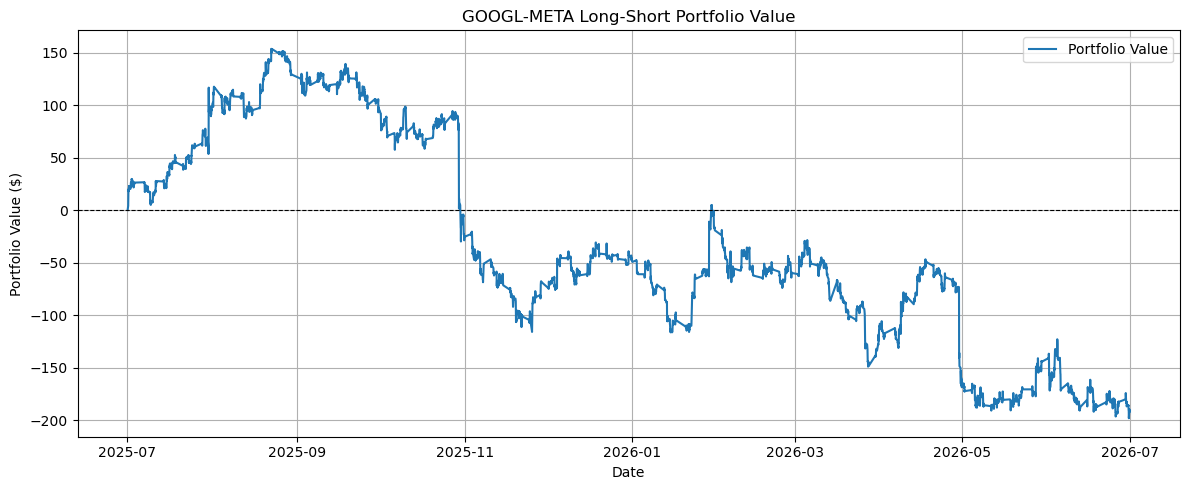

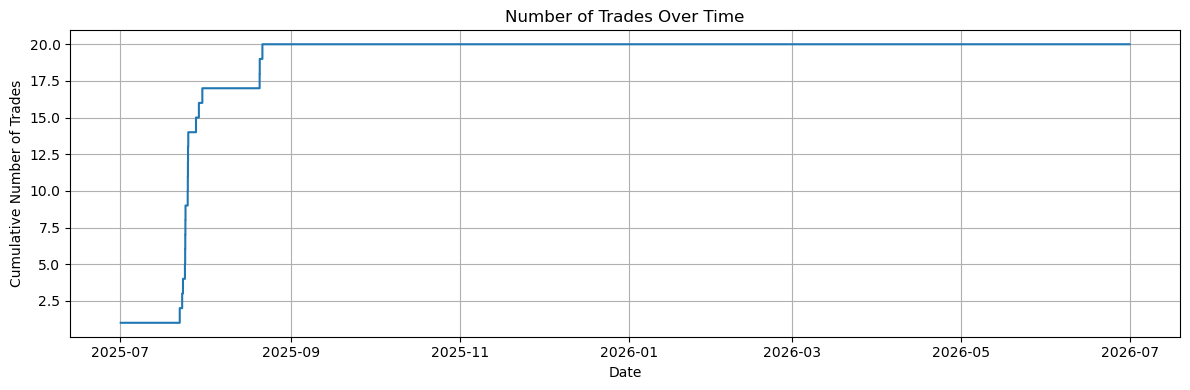

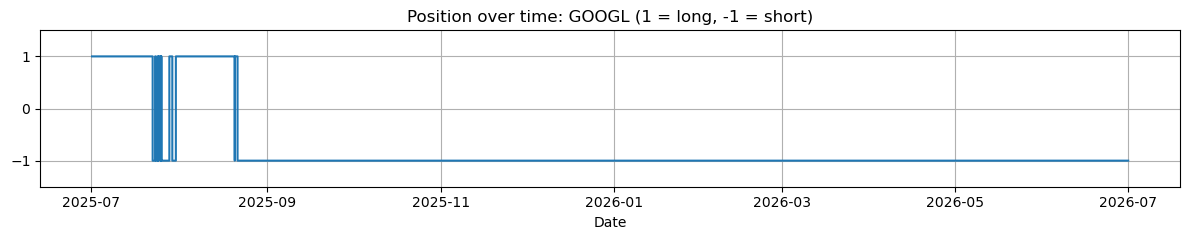

Final portfolio value: $ -191.41
Total number of trades: 20


In [ ]:
# Part 4: Performance evaluation — plots for portfolio value and number of trades
import matplotlib.pyplot as plt
import pandas as pd

# Prefer `test_results` (from Part 3); fall back to `test`
df = globals().get('test_results', globals().get('test', None))
if df is None:
    raise RuntimeError('No trading results found — run Part 3 first')

# Ensure cumulative trades column exists
if 'cum_trades' not in df.columns:
    df['cum_trades'] = df['trade_event'].cumsum()

# 1) Portfolio value over time
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['portfolio_value'], label='Portfolio Value')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.title('ENB-TRP Long-Short Portfolio Value')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 2) Cumulative number of trades (step plot)
plt.figure(figsize=(12, 4))
plt.step(df.index, df['cum_trades'], where='post')
plt.xlabel('Date')
plt.ylabel('Cumulative Number of Trades')
plt.title('Number of Trades Over Time')
plt.grid(True)
plt.tight_layout()
plt.show()

# 3) Position over time (ENB) — shows when we are long/short ENB
if 'position_ENB' in df.columns:
    plt.figure(figsize=(12, 2.5))
    plt.step(df.index, df['position_ENB'], where='post')
    plt.yticks([-1, 0, 1])
    plt.ylim(-1.5, 1.5)
    plt.xlabel('Date')
    plt.title('Position over time: ENB (1 = long, -1 = short)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Summary numbers
print('Final portfolio value: $', round(df['portfolio_value'].iloc[-1], 2))
print('Total number of trades:', int(df['trade_event'].sum()))
